In [6]:
# Cell 1 — Imports & basic config
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import joblib
from tqdm import tqdm
import os
tqdm.pandas()


In [7]:
from google.colab import drive
drive.mount("/content/Drive")

Mounted at /content/Drive


In [8]:
# Cell 2 — Load data (adjust paths)
DATA_PATH = os.path.join("/content/Drive/MyDrive/Amazon/68e8d1d70b66d_student_resource/student_resource/dataset")
train = pd.read_csv(os.path.join(DATA_PATH, "train.csv"), dtype={'sample_id': str})
test = pd.read_csv(os.path.join(DATA_PATH, "test.csv"), dtype={'sample_id': str})

# ensure catalog_content is string
train['catalog_content'] = train['catalog_content'].fillna('').astype(str)
test['catalog_content']  = test['catalog_content'].fillna('').astype(str)

print("Train rows:", len(train), "Test rows:", len(test))
train["catalog_content"][4]


Train rows: 75000 Test rows: 75000


'Item Name: kedem Sherry Cooking Wine, 12.7 Ounce - 12 per case.\nBullet Point: kedem Sherry Cooking Wine, 12.7 Ounce - 12 per case.\nValue: 12.0\nUnit: Count\n'

In [ ]:
#Catalog_Content:- Item Name,Bullet Train, Description , Ounce weight
# text: Item Name: Salerno Cookies, The Original Butter Cookies, 8 Ounce (Pack of 4) Bullet Point 1: Original Butter Cookies: Classic butter cookies made with real butter Bullet Point 2: Variety Pack: Includes 4 boxes with 32 cookies total Bullet Point 3: Occasion Perfect: Delicious cookies for birthdays, weddings, anniversaries Bullet Point 4: Shareable Treats: Fun to give and enjoy with friends and family Bullet Point 5: Salerno Brand: Trusted brand of delicious butter cookies since 1925 Value: 32.0 U

In [9]:
# Cell 3 — Enhanced text cleaning function
import re

def clean_text(s):
    s = str(s)

    # Normalize newlines/spaces
    s = re.sub(r'\r\n', '\n', s)
    s = re.sub(r'\u2019', "'", s)  # smart quote -> normal
    s = re.sub(r'\u2018', "'", s)  # another smart quote
    s = re.sub(r'\u201c|\u201d', '"', s)  # smart double quotes

    # Remove extra whitespace but keep structure
    # Collapse spaces/tabs but keep newlines intact
    s = re.sub(r'[ \t]+', ' ', s).strip()


    # Convert to lowercase for consistency (optional - test both ways)
    # s = s.lower()  # Uncomment if you want lowercase

    return s

train['catalog_content_clean'] = train['catalog_content'].progress_apply(clean_text)
test['catalog_content_clean']  = test['catalog_content'].progress_apply(clean_text)

print("Example cleaned text:", train['catalog_content_clean'].iloc[56])
print(f"\nTrain shape: {train.shape}")
print(f"Test shape: {test.shape}")

100%|██████████| 75000/75000 [00:08<00:00, 9040.45it/s]

Example cleaned text: Item Name: Zabaglione Strawberry Pu-erh Tea (50 tea bags, ZIN: 535909) - 3 Pack
Bullet Point 1: Our Zabaglione Strawberry Pu-erh Tea is a terrific flavored Pu-erh tea with Dried Strawberries and Strawberry Leaf that you can enjoy again and again! You will really enjoy the special Zabaglione Strawberry aroma and taste! - Ingredients: Pu-erh tea, Dried Strawberries, Strawberry Leaf and Natural Zabaglione Strawberry Flavor.
Bullet Point 2: No fillers.
Bullet Point 3: Manufacturer: TerraVita
Bullet Point 4: Size: 50 tea bags
Bullet Point 5: Pu-erh Tea Bags - Packed in a convenient upright pouch!
Product Description: Our Zabaglione Strawberry Pu-erh Tea is a terrific flavored Pu-erh tea with Dried Strawberries and Strawberry Leaf that you can enjoy again and again! You will really enjoy the special Zabaglione Strawberry aroma and taste! - Ingredients: Pu-erh tea, Dried Strawberries, Strawberry Leaf and Natural Zabaglione Strawberry Flavor. - Hot tea brewing method: Bri

In [6]:
train["catalog_content_clean"][56]

"Item Name: Zabaglione Strawberry Pu-erh Tea (50 tea bags, ZIN: 535909) - 3 Pack\nBullet Point 1: Our Zabaglione Strawberry Pu-erh Tea is a terrific flavored Pu-erh tea with Dried Strawberries and Strawberry Leaf that you can enjoy again and again! You will really enjoy the special Zabaglione Strawberry aroma and taste! - Ingredients: Pu-erh tea, Dried Strawberries, Strawberry Leaf and Natural Zabaglione Strawberry Flavor.\nBullet Point 2: No fillers.\nBullet Point 3: Manufacturer: TerraVita\nBullet Point 4: Size: 50 tea bags\nBullet Point 5: Pu-erh Tea Bags - Packed in a convenient upright pouch!\nProduct Description: Our Zabaglione Strawberry Pu-erh Tea is a terrific flavored Pu-erh tea with Dried Strawberries and Strawberry Leaf that you can enjoy again and again! You will really enjoy the special Zabaglione Strawberry aroma and taste! - Ingredients: Pu-erh tea, Dried Strawberries, Strawberry Leaf and Natural Zabaglione Strawberry Flavor. - Hot tea brewing method: Bring freshly draw

In [10]:
# Cell 4 — Catalog parsing (minimal changes only)

field_patterns = {
    'item_name': r'Item Name:\s*(.*?)(?:Bullet Point|Product Description:|Value:|Unit:|$)',
    'product_description': r'Product Description:\s*(.*?)(?:Value:|Unit:|$)',
    'value': r'Value:\s*([\d\.]+)',
    'unit': r'Unit:\s*([A-Za-z0-9\.\s%/()-]+)'
}

bullet_pattern = r'Bullet Point\s*\d+:\s*(.*?)(?=Bullet Point\s*\d+:|Product Description:|Value:|Unit:|$)'

# Catalog parser
def parse_catalog(text):
    t = text or ""
    out = {}

    # Item Name
    m = re.search(field_patterns['item_name'], t, flags=re.IGNORECASE | re.DOTALL)
    out['item_name'] = (m.group(1).strip() if m and m.group(1) else '').strip()

    # Bullet Points
    bullets = re.findall(bullet_pattern, t, flags=re.IGNORECASE | re.DOTALL)
    out['bullets'] = [b.strip() for b in bullets if b.strip()]

    # Product Description
    m = re.search(field_patterns['product_description'], t, flags=re.IGNORECASE | re.DOTALL)
    out['product_description'] = (m.group(1).strip() if m and m.group(1) else '').strip()

    # Value (numeric)
    m = re.search(field_patterns['value'], t, flags=re.IGNORECASE)
    out['value'] = float(m.group(1)) if m else np.nan

    # Unit
    m = re.search(field_patterns['unit'], t, flags=re.IGNORECASE)
    out['unit'] = (m.group(1).strip() if m and m.group(1) else '').strip()

    return out

# Apply parsing
print("Parsing train data...")
train_parsed = train['catalog_content_clean'].progress_apply(parse_catalog).apply(pd.Series)

print("Parsing test data...")
test_parsed = test['catalog_content_clean'].progress_apply(parse_catalog).apply(pd.Series)

# Drop existing parsed columns before merging
parsed_cols = ['item_name', 'bullets', 'product_description', 'value', 'unit']
train = train.drop(columns=[col for col in parsed_cols if col in train.columns])
test = test.drop(columns=[col for col in parsed_cols if col in test.columns])

# Merge parsed columns
train = pd.concat([train, train_parsed], axis=1)
test = pd.concat([test, test_parsed], axis=1)

# Printing examples
print("\nExample item name:", train['item_name'].iloc[0])
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Parsing train data...


100%|██████████| 75000/75000 [00:11<00:00, 6645.59it/s]


Parsing test data...


100%|██████████| 75000/75000 [00:11<00:00, 6750.82it/s]



Example item name: La Victoria Green Taco Sauce Mild, 12 Ounce (Pack of 6)
Train shape: (75000, 10)
Test shape: (75000, 9)


In [ ]:

train['item_name'][40]

'Celestial Seasonings Herbal Tea, Red Zinger, 20 Count'

In [11]:
# Cell 5 — Enhanced brand extraction and pack quantity extraction

import re

def extract_brand(item_name):
    """
    Extract probable brand from item name.
    Assumes brand appears at the beginning.
    """
    if not item_name:
        return "unknown"

    text = item_name.strip()

    # Colon-based brand
    if ":" in text:
        return text.split(":", 1)[0].strip()

    # First 1–3 Capitalized words = brand
    m = re.match(r'^((?:[A-Z][a-zA-Z&\'\-]+)(?:\s+[A-Z][a-zA-Z&\'\-]+){0,2})\b', text)
    if m:
        return m.group(1).strip()

    return "unknown"


def extract_pack_quantity(text):
    """
    Extract pack quantity like:
    - 20 Count
    - 20 ct
    - Pack of 20
    """
    if not text:
        return None

    t = text.lower()

    patterns = [
        r'pack of\s*(\d+)',
        r'(\d+)\s*(count|ct|pcs|pieces)\b',
        r'\b(\d+)\s*[-]?\s*(pack)\b'
    ]

    for p in patterns:
        m = re.search(p, t)
        if m:
            return int(m.group(1))

    return None


def clean_item_name(item_name, brand, pack_qty):
    """
    Remove brand and quantity info from item name
    """
    if not item_name:
        return None

    name = item_name

    # Remove brand
    if brand and brand != "unknown":
        name = re.sub(rf'^{re.escape(brand)}[\s,]*', '', name, flags=re.I)

    # Remove quantity patterns
    name = re.sub(r'\b\d+\s*(count|ct|pcs|pieces|pack)\b', '', name, flags=re.I)
    name = re.sub(r'pack of\s*\d+', '', name, flags=re.I)

    # Remove leftover commas & extra spaces
    name = re.sub(r'[,\-]+', ' ', name)
    name = re.sub(r'\s+', ' ', name).strip()

    return name





# Apply both
print("Extracting brand...")
train['brand'] = train['item_name'].progress_apply(extract_brand)
test['brand'] = test['item_name'].progress_apply(extract_brand)

print("Extracting pack quantity...")
train['pack_quantity'] = train['item_name'].progress_apply(extract_pack_quantity)
test['pack_quantity'] = test['item_name'].progress_apply(extract_pack_quantity)

print("Cleaning item names...")
train['item_clean'] = train.apply(
    lambda x: clean_item_name(x['item_name'], x['brand'], x['pack_quantity']),
    axis=1
)
test['item_clean'] = test.apply(
    lambda x: clean_item_name(x['item_name'], x['brand'], x['pack_quantity']),
    axis=1
)
train.head(2)

Extracting brand...


100%|██████████| 75000/75000 [00:00<00:00, 413027.92it/s]


Extracting pack quantity...


100%|██████████| 75000/75000 [00:00<00:00, 147447.59it/s]


Cleaning item names...


,sample_id,catalog_content,image_link,price,catalog_content_clean,item_name,bullets,product_description,value,unit,brand,pack_quantity,item_clean
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,"Item Name: La Victoria Green Taco Sauce Mild, ...","La Victoria Green Taco Sauce Mild, 12 Ounce (P...",[],,72.0,Fl Oz,La Victoria Green,6.0,Taco Sauce Mild 12 Ounce ()
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,"Item Name: Salerno Cookies, The Original Butte...","Salerno Cookies, The Original Butter Cookies, ...",[Original Butter Cookies: Classic butter cooki...,,32.0,Ounce,Salerno Cookies,4.0,The Original Butter Cookies 8 Ounce ()


In [12]:
# Cell 6 — Enhanced handcrafted features from text
#strong premium
strong_premium = [
    "premium", "luxury", "elite", "exclusive", "signature", "heritage",
    "artisan", "handcrafted", "craft", "limited", "reserve",
    "gourmet", "finest", "select", "master", "masterpiece",
    "flagship", "prestige", "opulent"
]

#organic premium
organic_premium = [
    "organic", "natural", "pure", "clean", "eco", "eco-friendly",
    "sustainable", "non-gmo", "vegan", "plant-based",
    "cold-pressed", "raw", "whole", "bio", "green"
]
#food premium
food_premium = [
    "gourmet", "artisan", "handmade", "small-batch",
    "estate", "single-origin", "aged", "reserve",
    "barrel-aged", "stone-ground", "farmhouse"
]
#fashion premium
fashion_premium = [
    "designer", "couture", "tailored", "bespoke",
    "signature", "runway", "collection",
    "heritage", "iconic"
]
#tech premium
tech_premium = [
    "pro", "max", "ultra", "plus", "advanced",
    "flagship", "studio", "performance",
    "high-end", "precision"
]
#perception
perception_premium = [
    "classic", "timeless", "authentic",
    "original", "genuine", "trusted",
    "refined", "elegant", "modern"
]
#
noisy_premium = [
    "best", "top", "quality", "value",
    "new", "special", "recommended"
]
premium_keywords = list(set(
    strong_premium +
    organic_premium +
    food_premium +
    fashion_premium +
    tech_premium +
    perception_premium
))


def make_text_features(df):
    df = df.copy()

    # ===== Basic text length features =====
    df['item_name_len_chars'] = df['item_name'].fillna('').apply(len)
    df['item_name_len_words'] = df['item_name'].fillna('').apply(lambda x: len(str(x).split()))

    # ===== Bullet point features =====
    df['bullet_count'] = df['bullets'].apply(lambda b: len(b) if isinstance(b, list) else 0)
    df['bullets_len_chars'] = df['bullets'].apply(lambda b: sum(len(x) for x in b) if isinstance(b, list) else 0)
    df['avg_bullet_length'] = df.apply(
        lambda row: row['bullets_len_chars'] / row['bullet_count'] if row['bullet_count'] > 0 else 0,
        axis=1
    )

    # ===== Description features =====
    df['desc_len_chars'] = df['product_description'].fillna('').apply(len)
    df['desc_word_count'] = df['product_description'].fillna('').apply(lambda x: len(str(x).split()))

    # ===== Total text length =====
    df['total_text_length'] = df['item_name_len_chars'] + df['bullets_len_chars'] + df['desc_len_chars']

    # ===== Numeric token features =====
    df['num_token_count'] = df['catalog_content_clean'].apply(lambda s: len(re.findall(r'\d+(\.\d+)?', str(s))))

    # Extract all numbers and compute statistics
    def extract_number_stats(text):
        numbers = re.findall(r'\d+\.?\d*', str(text))
        numbers = [float(n) for n in numbers if float(n) > 0]
        if numbers:
            return {
                'max_number': max(numbers),
                'min_number': min(numbers),
                'mean_number': np.mean(numbers),
                'sum_numbers': sum(numbers)
            }
        return {'max_number': 0, 'min_number': 0, 'mean_number': 0, 'sum_numbers': 0}

    num_stats = df['catalog_content_clean'].apply(extract_number_stats).apply(pd.Series)
    df = pd.concat([df, num_stats], axis=1)

    # ===== Premium indicators =====
    df['has_premium_word'] = df['catalog_content_clean'].apply(
        lambda s: int(any(pk in str(s).lower() for pk in premium_keywords))
    )
    df['premium_word_count'] = df['catalog_content_clean'].apply(
        lambda s: sum(1 for pk in premium_keywords if pk in str(s).lower())
    )

    # ===== Value and unit features =====
    df['value_num'] = df['value'].fillna(0)  # Use 0 instead of NaN for tree models
    df['unit'] = df['unit'].fillna('').apply(lambda x: str(x).strip())

    # ===== Weight/size detection =====
    df['has_weight_unit'] = df['catalog_content_clean'].str.contains(
        r'(oz|ounce|ml|l|kg|g|fl oz|oz\.|pound|lb)',
        case=False, regex=True, na=False
    ).astype(int)

    # ===== Total weight calculation (value * pack_quantity) =====
    df['total_weight'] = df['value_num'] * df['pack_quantity']

    # ===== Brand features =====
    df['brand'] = df['brand'].fillna('unknown').astype(str).str.lower().str.strip()

    # ===== Capital letter ratio (premium products often have better formatting) =====
    df['capital_ratio'] = df['catalog_content_clean'].apply(
        lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x)) if len(str(x)) > 0 else 0
    )

    # ===== Special characters (richer descriptions) =====
    df['exclamation_count'] = df['catalog_content_clean'].str.count('!')
    df['comma_count'] = df['catalog_content_clean'].str.count(',')

    # ===== Price per unit features =====
    df['value_per_pack'] = df.apply(
        lambda row: row['value_num'] / row['pack_quantity'] if row['pack_quantity'] > 0 else row['value_num'],
        axis=1
    )

    return df

print("Creating handcrafted features for train...")
train = make_text_features(train)

print("Creating handcrafted features for test...")
test = make_text_features(test)

print("\n" + "="*60)
print("FEATURE ENGINEERING RESULTS")
print("="*60)
print(f"Total features created: {len([c for c in train.columns if c not in ['sample_id', 'catalog_content', 'catalog_content_clean', 'price']])}")
print(f"\nNew numeric features:")
print(f"  - premium_word_count: {train['premium_word_count'].value_counts().head()}")

train.head(2)

Creating handcrafted features for train...
Creating handcrafted features for test...

FEATURE ENGINEERING RESULTS
Total features created: 31

New numeric features:
  - premium_word_count: premium_word_count
1    16720
0    13132
2    12279
3     8352
4     6159
Name: count, dtype: int64


,sample_id,catalog_content,image_link,price,catalog_content_clean,item_name,bullets,product_description,value,unit,...,sum_numbers,has_premium_word,premium_word_count,value_num,has_weight_unit,total_weight,capital_ratio,exclamation_count,comma_count,value_per_pack
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,"Item Name: La Victoria Green Taco Sauce Mild, ...","La Victoria Green Taco Sauce Mild, 12 Ounce (P...",[],,72.0,Fl Oz,...,90.0,1,1,72.0,1,432.0,0.155556,0,1,12.0
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,"Item Name: Salerno Cookies, The Original Butte...","Salerno Cookies, The Original Butter Cookies, ...",[Original Butter Cookies: Classic butter cooki...,,32.0,Ounce,...,2020.0,1,3,32.0,1,128.0,0.076471,0,4,8.0


In [13]:
# Run this to decide:
brand_counts = train['brand'].value_counts()
print(f"Brands appearing 1 time: {(brand_counts == 1).sum()}")
print(f"Brands appearing 2-4 times: {((brand_counts >= 2) & (brand_counts <= 4)).sum()}")
print(f"Brands appearing 5+ times: {(brand_counts >= 5).sum()}")
print(f"\nTotal unique brands: {len(brand_counts)}")

Brands appearing 1 time: 30942
Brands appearing 2-4 times: 8039
Brands appearing 5+ times: 1806

Total unique brands: 40787


In [14]:
train = train.loc[:, ~train.columns.duplicated()]
test  = test.loc[:, ~test.columns.duplicated()]
train_image=train.copy()
test_image=test.copy()

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sample_id              75000 non-null  object 
 1   catalog_content        75000 non-null  object 
 2   image_link             75000 non-null  object 
 3   price                  75000 non-null  float64
 4   catalog_content_clean  75000 non-null  object 
 5   brand                  75000 non-null  object 
 6   pack_quantity          32251 non-null  float64
 7   item_clean             74992 non-null  object 
 8   item_name              75000 non-null  object 
 9   bullets                75000 non-null  object 
 10  product_description    75000 non-null  object 
 11  value                  74060 non-null  float64
 12  unit                   75000 non-null  object 
 13  item_name_len_chars    75000 non-null  int64  
 14  item_name_len_words    75000 non-null  int64  
 15  bu

In [15]:
DROP_ALWAYS = [
    "image_link",
    "catalog_content",
    "bullets",
    "product_description"
]

train_tab=train.drop(columns=DROP_ALWAYS)
test_tab=test.drop(columns=DROP_ALWAYS)
train_tab['value_per_pack'].isnull().sum()

np.int64(0)

In [16]:
from sklearn.preprocessing import LabelEncoder
import joblib
import numpy as np

# ===== BRAND =====
train_brand = train_tab['brand'].fillna('unknown').astype(str)
test_brand  = test_tab['brand'].fillna('unknown').astype(str)

# FORCE 'unknown' to exist in training
if 'unknown' not in train_brand.values:
    train_brand = pd.concat(
        [train_brand, pd.Series(['unknown'])],
        ignore_index=True
    )

le_brand = LabelEncoder()
le_brand.fit(train_brand)

# transform safely
train_tab['brand_enc'] = le_brand.transform(
    train_tab['brand'].fillna('unknown').astype(str)
)

test_tab['brand_enc'] = le_brand.transform(
    test_brand.where(test_brand.isin(le_brand.classes_), 'unknown')
)
# ===== UNIT =====
train_unit = train_tab['unit'].fillna('').astype(str)
test_unit  = test_tab['unit'].fillna('').astype(str)

if '' not in train_unit.values:
    train_unit = pd.concat(
        [train_unit, pd.Series([''])],
        ignore_index=True
    )

le_unit = LabelEncoder()
le_unit.fit(train_unit)

train_tab['unit_enc'] = le_unit.transform(train_unit.iloc[:len(train)])
test_tab['unit_enc'] = le_unit.transform(
    test_unit.where(test_unit.isin(le_unit.classes_), '')
)


joblib.dump(le_brand, 'le_brand.joblib')
joblib.dump(le_unit, 'le_unit.joblib')


['le_unit.joblib']

In [17]:
# Cell 8 — TF-IDF vectorization (fit on TRAIN then transform TEST)
# Choose max_features reasonably (e.g., 300 or 1000 depending on memory)


TFIDF_FEATURES = 2500  # Increased from 300 for better coverage

# Optimized TF-IDF parameters
tfidf = TfidfVectorizer(
    max_features=TFIDF_FEATURES,
    ngram_range=(1, 2),           # Unigrams + bigrams
    min_df=3,                     # Ignore very rare terms
    max_df=0.95,                  # Ignore very common terms (almost in all docs)
    sublinear_tf=True,            # Use log scaling for term frequency
    strip_accents='unicode',      # Remove accents
    lowercase=True,               # Convert to lowercase
    stop_words=None               # Keep all words (product names matter!)
)

print("Fitting TF-IDF on train data...")
X_text_tfidf_train = tfidf.fit_transform(train_tab['catalog_content_clean'].fillna(''))

print("Transforming test data...")
X_text_tfidf_test = tfidf.transform(test_tab['catalog_content_clean'].fillna(''))

print("\n" + "="*60)
print("TF-IDF RESULTS")
print("="*60)
print(f"TF-IDF shape (train): {X_text_tfidf_train.shape}")
print(f"TF-IDF shape (test):  {X_text_tfidf_test.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"Sparsity: {(1.0 - X_text_tfidf_train.nnz / (X_text_tfidf_train.shape[0] * X_text_tfidf_train.shape[1])) * 100:.2f}%")

# Show top TF-IDF features
feature_names = tfidf.get_feature_names_out()
print(f"\nSample features (first 10): {list(feature_names[:10])}")

# Save vectorizer


print("TF-IDF shape (train):", X_text_tfidf_train.shape)
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')


Fitting TF-IDF on train data...
Transforming test data...

TF-IDF RESULTS
TF-IDF shape (train): (75000, 2500)
TF-IDF shape (test):  (75000, 2500)
Vocabulary size: 2500
Sparsity: 96.46%

Sample features (first 10): ['0g', '10', '10 ounce', '10 oz', '10 unit', '100', '100 arabica', '100 natural', '100 pure', '11']
TF-IDF shape (train): (75000, 2500)


['tfidf_vectorizer.joblib']

In [18]:
 # Cell 9 — Build comprehensive DataFrame of handcrafted features with correlation analysis

# Updated handcrafted columns (include all new features from Cell 6)
handcrafted_cols = [
    'sample_id',
    # Text length features
    'item_name_len_chars', 'item_name_len_words',
    'bullet_count', 'bullets_len_chars', 'avg_bullet_length',
    'desc_len_chars', 'desc_word_count', 'total_text_length',
    # Numeric features
    'num_token_count', 'max_number', 'min_number', 'mean_number', 'sum_numbers',
    # Premium indicators
    'has_premium_word', 'premium_word_count',
    # Value and weight
    'value_num', 'pack_quantity', 'total_weight', 'value_per_pack',
    'has_weight_unit',
    # Categorical encodings
    'brand_enc', 'unit_enc',
    # Text quality
    'capital_ratio', 'exclamation_count', 'comma_count'
]

# Create dataframes
train_hand = train_tab[handcrafted_cols + ['price']].copy()
test_hand = test_tab[handcrafted_cols].copy()

# Fill NaNs (for safety)
numeric_cols = train_hand.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if col != 'price' and col != 'sample_id':
        train_hand[col] = train_hand[col].fillna(0)  # Use 0 instead of -1
        test_hand[col] = test_hand[col].fillna(0)

# Convert sample_id to string
train_hand['sample_id'] = train_hand['sample_id'].astype(str)
test_hand['sample_id'] = test_hand['sample_id'].astype(str)

print("="*60)
print("HANDCRAFTED FEATURES SUMMARY")
print("="*60)
print(f"Total handcrafted features: {len(handcrafted_cols) - 1}")  # -1 for sample_id
print(f"Train shape: {train_hand.shape}")
print(f"Test shape: {test_hand.shape}")

# ===== CORRELATION ANALYSIS WITH PRICE =====
print("\n" + "="*60)
print("TOP FEATURES CORRELATED WITH PRICE")
print("="*60)

# Calculate correlations
correlations = train_hand.corr()['price'].drop('price').sort_values(ascending=False)

print("\n🔺 TOP 10 POSITIVE CORRELATIONS (higher value = higher price):")
print(correlations.head(10).to_string())

print("\n🔻 TOP 10 NEGATIVE CORRELATIONS (higher value = lower price):")
print(correlations.tail(10).to_string())

# Check for weak features (abs correlation < 0.05)
weak_features = correlations[abs(correlations) < 0.05]
if len(weak_features) > 0:
    print(f"\n⚠️  Weak features (|correlation| < 0.05): {len(weak_features)}")
    print(weak_features.to_string())

# ===== FEATURE STATISTICS =====
print("\n" + "="*60)
print("KEY FEATURE STATISTICS")
print("="*60)

key_features = ['total_weight', 'pack_quantity', 'value_num', 'max_number',
                'premium_word_count', 'brand_frequency']

for feat in key_features:
    if feat in train_hand.columns:
        print(f"\n{feat}:")
        print(f"  Mean: {train_hand[feat].mean():.2f}, Median: {train_hand[feat].median():.2f}")
        print(f"  Min: {train_hand[feat].min():.2f}, Max: {train_hand[feat].max():.2f}")
        print(f"  Non-zero: {(train_hand[feat] > 0).sum()} ({(train_hand[feat] > 0).sum()/len(train_hand)*100:.1f}%)")

# ===== MISSING VALUES CHECK =====
print("\n" + "="*60)
print("MISSING VALUES CHECK")
print("="*60)
missing = train_hand.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("✅ No missing values!")

# Display correlation matrix (optional - can comment out)
# print("\nFull correlation matrix:")
# print(train_hand.corr().round(2))

HANDCRAFTED FEATURES SUMMARY
Total handcrafted features: 25
Train shape: (75000, 27)
Test shape: (75000, 26)

TOP FEATURES CORRELATED WITH PRICE

🔺 TOP 10 POSITIVE CORRELATIONS (higher value = higher price):
desc_len_chars         0.179825
desc_word_count        0.179811
total_text_length      0.146795
premium_word_count     0.139841
num_token_count        0.138371
comma_count            0.109682
exclamation_count      0.099634
item_name_len_words    0.093614
item_name_len_chars    0.086788
has_premium_word       0.067825

🔻 TOP 10 NEGATIVE CORRELATIONS (higher value = lower price):
pack_quantity      0.009021
min_number         0.002433
max_number        -0.001110
sum_numbers       -0.001142
mean_number       -0.002361
brand_enc         -0.012737
sample_id         -0.025731
capital_ratio     -0.065209
unit_enc          -0.087757
has_weight_unit         NaN

⚠️  Weak features (|correlation| < 0.05): 10
avg_bullet_length    0.044322
bullet_count         0.017554
total_weight         0.0

In [ ]:
train_tab.isnull().sum()

,0
price,0
catalog_content_clean,0
brand,0
pack_quantity,42749
item_clean,8
item_name,0
value,940
unit,0
item_name_len_chars,0
item_name_len_words,0


<Axes: >

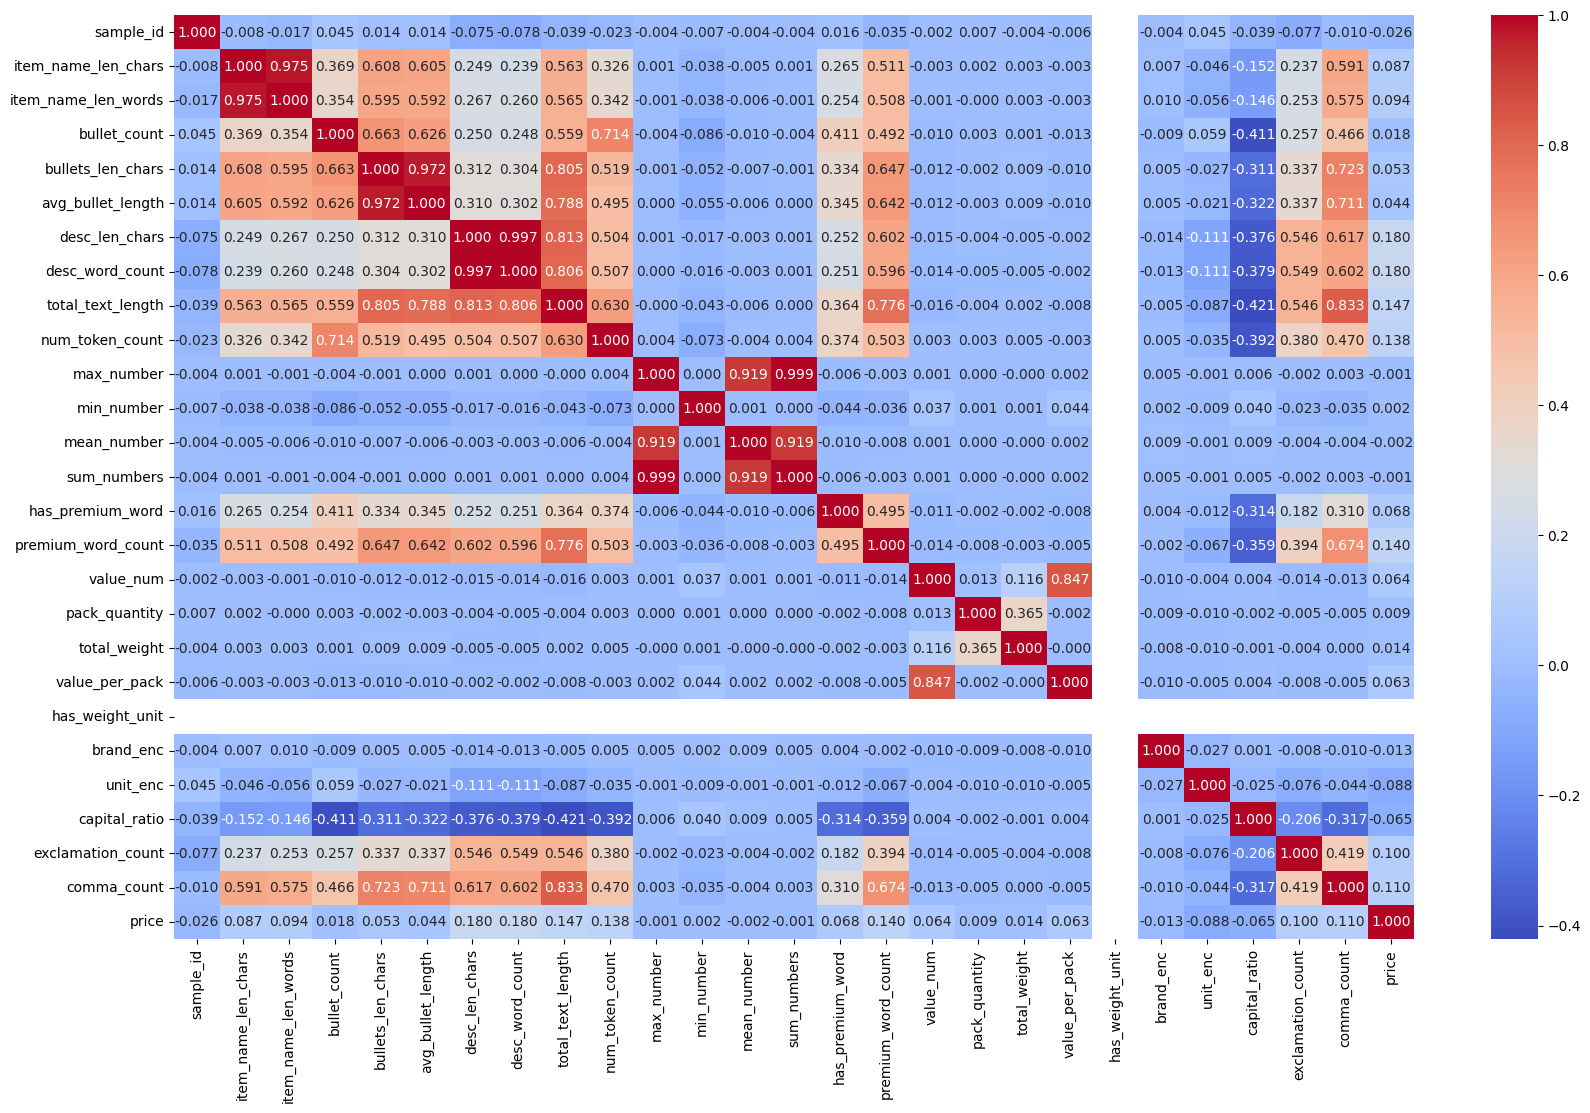

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(20, 12))
sns.heatmap(train_hand.corr(), annot=True, fmt=".3f", cmap="coolwarm")


In [19]:
# Cell 10 — Combine TF-IDF + handcrafted features into final datasets

import scipy.sparse as sp

# Convert sparse -> dense (FIXED: correct train/test assignment)
print("Converting TF-IDF to dense arrays...")
tfidf_train_dense = X_text_tfidf_train.toarray()  # ✅ TRAIN data
tfidf_test_dense = X_text_tfidf_test.toarray()    # ✅ TEST data

print(f"TF-IDF train shape: {tfidf_train_dense.shape}")
print(f"TF-IDF test shape: {tfidf_test_dense.shape}")

# Create TF-IDF DataFrames
tfidf_colnames = [f"tfidf_{i}" for i in range(tfidf_train_dense.shape[1])]
df_tfidf_train = pd.DataFrame(tfidf_train_dense, columns=tfidf_colnames)
df_tfidf_test = pd.DataFrame(tfidf_test_dense, columns=tfidf_colnames)

# Concatenate handcrafted + TF-IDF features
print("\nCombining handcrafted and TF-IDF features...")
train_combined = pd.concat([
    train_hand.reset_index(drop=True),
    df_tfidf_train.reset_index(drop=True)
], axis=1)

test_combined = pd.concat([
    test_hand.reset_index(drop=True),
    df_tfidf_test.reset_index(drop=True)
], axis=1)

print("\n" + "="*60)
print("FINAL COMBINED DATASETS")
print("="*60)
print(f"Train combined shape: {train_combined.shape}")
print(f"Test combined shape:  {test_combined.shape}")
print(f"\nFeature breakdown:")
print(f"  - Handcrafted features: {len(train_hand.columns) - 1}")  # -1 for sample_id
print(f"  - TF-IDF features: {len(tfidf_colnames)}")
print(f"  - Total features: {train_combined.shape[1] - 2}")  # -2 for sample_id and price

# Verify no data leakage
print(f"\nData integrity check:")
print(f"  ✅ Train has 'price' column: {'price' in train_combined.columns}")
print(f"  ✅ Test does NOT have 'price' column: {'price' not in test_combined.columns}")
print(f"  ✅ Both have 'sample_id': {'sample_id' in train_combined.columns and 'sample_id' in test_combined.columns}")

# Show sample
print(f"\nTrain sample (first 3 rows, first 10 columns):")
print(train_combined.iloc[:3, :10])

print(f"\nTest sample (first 3 rows, first 10 columns):")
print(test_combined.iloc[:3, :10])

Converting TF-IDF to dense arrays...
TF-IDF train shape: (75000, 2500)
TF-IDF test shape: (75000, 2500)

Combining handcrafted and TF-IDF features...

FINAL COMBINED DATASETS
Train combined shape: (75000, 2527)
Test combined shape:  (75000, 2526)

Feature breakdown:
  - Handcrafted features: 26
  - TF-IDF features: 2500
  - Total features: 2525

Data integrity check:
  ✅ Train has 'price' column: True
  ✅ Test does NOT have 'price' column: True
  ✅ Both have 'sample_id': True

Train sample (first 3 rows, first 10 columns):
  sample_id  item_name_len_chars  item_name_len_words  bullet_count  \
0     33127                   55                   11             0   
1    198967                   65                   11             5   
2    261251                   76                   14             5   

   bullets_len_chars  avg_bullet_length  desc_len_chars  desc_word_count  \
0                  0                0.0               0                0   
1                325              

In [20]:
import pandas as pd
import numpy as np

# Handcrafted feature names (already known)
handcrafted_features = [
    'item_name_len_chars', 'item_name_len_words',
    'bullet_count', 'bullets_len_chars', 'avg_bullet_length',
    'desc_len_chars', 'desc_word_count', 'total_text_length',
    'num_token_count', 'max_number', 'min_number',
    'mean_number', 'sum_numbers',
    'has_premium_word', 'premium_word_count',
    'value_num', 'pack_quantity', 'total_weight',
    'value_per_pack', 'has_weight_unit',
    'brand_enc', 'unit_enc',
    'capital_ratio', 'exclamation_count', 'comma_count'
]

# Compute correlations
hand_corr = (
    train_combined[handcrafted_features + ['price']]
    .corr()['price']
    .drop('price')
    .sort_values(key=np.abs, ascending=False)
)

hand_corr.head(10)


,price
desc_len_chars,0.179825
desc_word_count,0.179811
total_text_length,0.146795
premium_word_count,0.139841
num_token_count,0.138371
comma_count,0.109682
exclamation_count,0.099634
item_name_len_words,0.093614
unit_enc,-0.087757
item_name_len_chars,0.086788


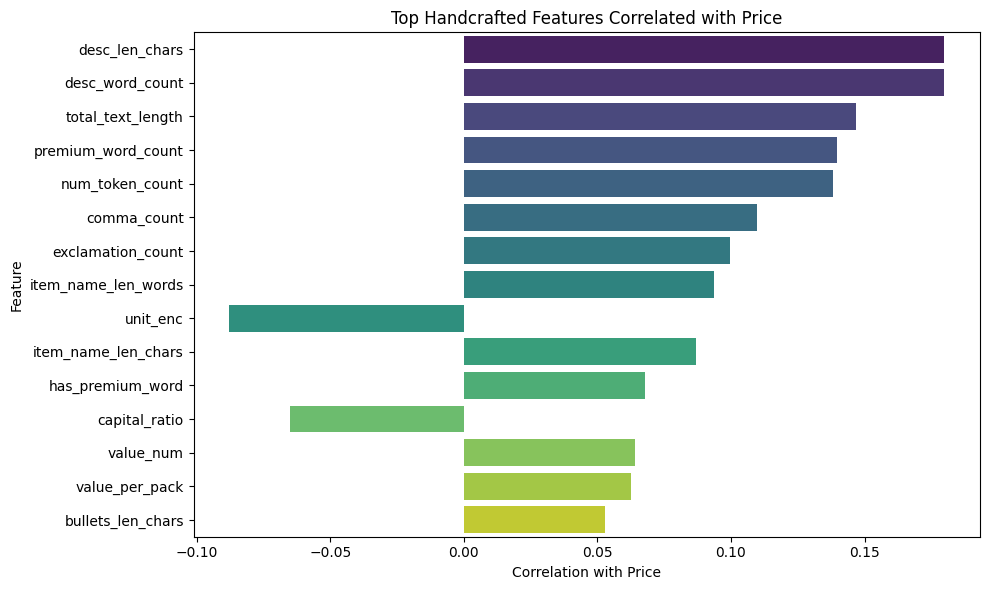

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

TOP_N = 15

plt.figure(figsize=(10, 6))
sns.barplot(
    x=hand_corr.head(TOP_N).values,
    y=hand_corr.head(TOP_N).index,
    palette="viridis"
)

plt.title("Top Handcrafted Features Correlated with Price")
plt.xlabel("Correlation with Price")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [22]:
# Identify TF-IDF columns
tfidf_cols = [c for c in train_combined.columns if c.startswith("tfidf_")]

# Compute correlation efficiently
tfidf_corr = []

price = train_combined["price"].values

for col in tfidf_cols:
    vec = train_combined[col].values
    if vec.std() == 0:
        continue
    corr = np.corrcoef(vec, price)[0, 1]
    tfidf_corr.append((col, corr))

tfidf_corr_df = pd.DataFrame(tfidf_corr, columns=["tfidf_col", "correlation"])
tfidf_corr_df["abs_corr"] = tfidf_corr_df["correlation"].abs()
tfidf_corr_df = tfidf_corr_df.sort_values("abs_corr", ascending=False)


In [23]:
# Load vectorizer
import joblib
tfidf_vectorizer = joblib.load("tfidf_vectorizer.joblib")

terms = tfidf_vectorizer.get_feature_names_out()

tfidf_corr_df["term"] = tfidf_corr_df["tfidf_col"].apply(
    lambda x: terms[int(x.split("_")[1])]
)

tfidf_corr_df.head(10)


,tfidf_col,correlation,abs_corr,term
1594,tfidf_1594,0.222821,0.222821,per case
418,tfidf_418,0.207904,0.207904,case
2101,tfidf_2101,0.185018,0.185018,terravita
2102,tfidf_2102,0.180942,0.180942,terravita bullet
1698,tfidf_1698,0.173713,0.173713,pouch product
206,tfidf_206,0.167667,0.167667,are prepared
1657,tfidf_1657,0.166852,0.166852,point manufacturer
2287,tfidf_2287,0.165559,0.165559,upright pouch
532,tfidf_532,0.165559,0.165559,convenient upright
1291,tfidf_1291,0.165493,0.165493,manufacturer terravita


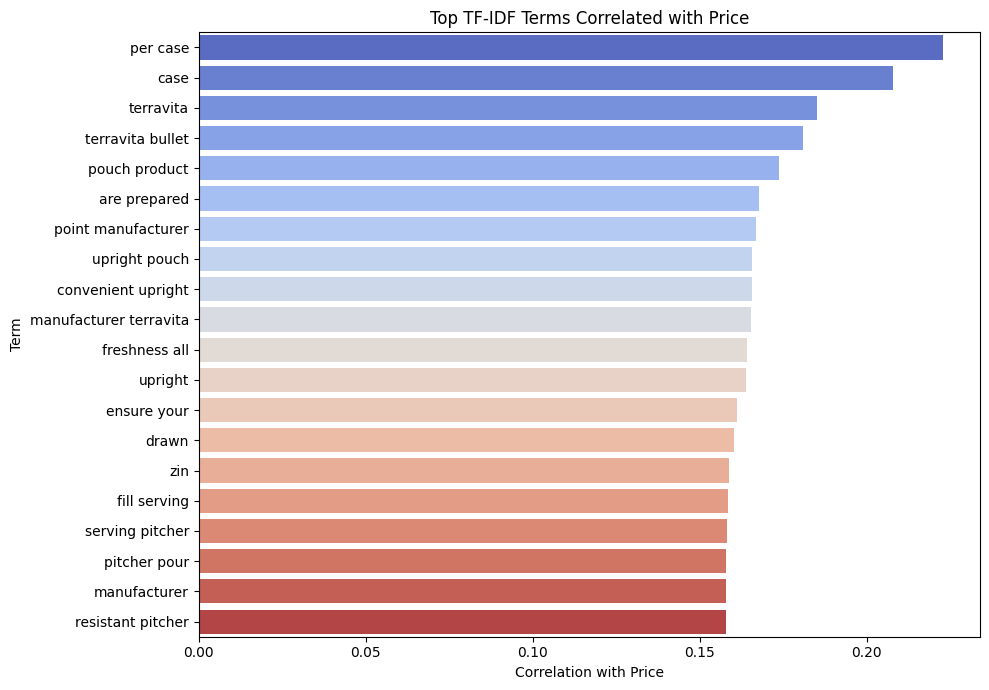

In [24]:
TOP_N = 20
top_tfidf = tfidf_corr_df.head(TOP_N)

plt.figure(figsize=(10, 7))
sns.barplot(
    x=top_tfidf["correlation"],
    y=top_tfidf["term"],
    palette="coolwarm"
)

plt.title("Top TF-IDF Terms Correlated with Price")
plt.xlabel("Correlation with Price")
plt.ylabel("Term")
plt.tight_layout()
plt.show()


In [28]:
# Cell 11 — Save processed files
train_combined.to_csv("/content/Drive/MyDrive/Amazon/train_processed_text.csv", index=False)
test_combined.to_csv("/content/Drive/MyDrive/Amazon/test_processed_text.csv", index=False)

# Also save sparse TF-IDF matrices if needed
sp.save_npz("/content/Drive/MyDrive/Amazon/tfidf_train_sparse.npz", X_text_tfidf_train)
sp.save_npz("/content/Drive/MyDrive/Amazon/tfidf_test_sparse.npz", X_text_tfidf_test)

print("Saved: train_processed_text.csv, test_processed_text.csv, tfidf_train_sparse.npz")


FileNotFoundError: [Errno 2] No such file or directory: '/content/Drive/MyDrive/Amazon/test_processed_text/tfidf_test_sparse.npz'

In [25]:
#Image Extraction
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
import urllib.request
import warnings
warnings.filterwarnings("ignore")

IMAGE_KEEP_COLS = [
    "sample_id",
    "image_link",
    "item_clean",   # text visible on image (VERY IMPORTANT)
    "brand",
    "price"         # only for train
]

train_image = train_image.loc[:, IMAGE_KEEP_COLS].copy()
test_image  = test_image.loc[:, IMAGE_KEEP_COLS[:-1]].copy()  # no price

train_image.drop_duplicates("sample_id", inplace=True)
test_image.drop_duplicates("sample_id", inplace=True)

print(train_image.shape, test_image.shape)


(75000, 5) (75000, 4)


In [33]:
def download_image(url, save_dir):
    try:
        fname = Path(url).name.split("?")[0]
        save_path = os.path.join(save_dir, fname)
        if not os.path.exists(save_path):
            urllib.request.urlretrieve(url, save_path)
        return fname
    except:
        return None

In [ ]:
TEST_IMG_DIR = "images/test"
os.makedirs(TEST_IMG_DIR, exist_ok=True)

test_image["image_file"] = None

for i, row in tqdm(test_image.iterrows(), total=len(test_image)):
    fname = download_image(row["image_link"], TEST_IMG_DIR)
    test_image.at[i, "image_file"] = fname


  1%|▏         | 1116/75000 [03:10<1:58:01, 10.43it/s]

In [36]:
!mkdir -p "/content/Drive/MyDrive/Amazon/images/train"
!mkdir -p "/content/Drive/MyDrive/Amazon/images/test"


In [40]:
!rsync -av --progress /content/images/train/ "/content/Drive/MyDrive/Amazon/images/train/"
!rsync -av --progress /content/images/test/  "/content/Drive/MyDrive/Amazon/images/test/"



Streaming output truncated to the last 5000 lines.
        400,934 100%    1.66MB/s    0:00:00 (xfr#52865, to-chk=19089/71955)
81MtFPjompL.jpg
        469,929 100%    1.80MB/s    0:00:00 (xfr#52866, to-chk=19088/71955)
81MtK1O3U5L.jpg
        386,619 100%    1.24MB/s    0:00:00 (xfr#52867, to-chk=19087/71955)
81MtSNECAYL.jpg
        475,052 100%    1.39MB/s    0:00:00 (xfr#52868, to-chk=19086/71955)
81Mta115W7L.jpg
        316,125 100%  897.43kB/s    0:00:00 (xfr#52869, to-chk=19085/71955)
81MtpS8RrPL.jpg
        326,581 100%  859.64kB/s    0:00:00 (xfr#52870, to-chk=19084/71955)
81Mu0MmnenL.jpg
        275,728 100%  668.15kB/s    0:00:00 (xfr#52871, to-chk=19083/71955)
81Mu11VM0sL.jpg
        339,586 100%  783.99kB/s    0:00:00 (xfr#52872, to-chk=19082/71955)
81Mu6vBY-5L.jpg
        347,687 100%  761.30kB/s    0:00:00 (xfr#52873, to-chk=19081/71955)
81MuEQe7ZHL.jpg
        334,434 100%  678.99kB/s    0:00:00 (xfr#52874, to-chk=19080/71955)
81MujSEI3KL.jpg
        329,587 100%  636.09k

In [30]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
from sklearn.cluster import KMeans
import torchvision.models as models
import torchvision.transforms as transforms
TEST_IMG_DIR = "/content/images/test"   # your extracted test images
SAVE_PATH = "/content/Drive/MyDrive/Amazon/test_image_features.csv"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
model = models.resnet50(pretrained=True)
model.fc = torch.nn.Identity()   # 2048-d embedding
model.eval().to(device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


Using device: cpu


In [31]:
def extract_cnn_feature(img_path):
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = model(x).cpu().numpy().flatten()
    return feat


def get_image_metadata(img_path):
    img = Image.open(img_path)
    width, height = img.size
    file_size_kb = os.path.getsize(img_path) / 1024
    return width, height, round(file_size_kb, 2)


def extract_color_features(img_path, k=3):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    pixels = img.reshape(-1, 3)

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pixels)

    colors = kmeans.cluster_centers_.astype(int)
    hex_colors = [
        "#{:02x}{:02x}{:02x}".format(c[0], c[1], c[2]) for c in colors
    ]

    color_richness = np.std(pixels)
    return hex_colors, round(float(color_richness), 2)
records = []

for _, row in tqdm(test_image.iterrows(), total=len(test_image)):
    img_file = row["image_file"]
    if img_file is None:
        continue

    img_path = os.path.join(TEST_IMG_DIR, img_file)
    if not os.path.exists(img_path):
        continue

    try:
        width, height, file_size_kb = get_image_metadata(img_path)
        dominant_colors, color_richness = extract_color_features(img_path)
        cnn_feat = extract_cnn_feature(img_path)

        records.append({
            "sample_id": row["sample_id"],
            "width": width,
            "height": height,
            "file_size_kb": file_size_kb,
            "dominant_colors": str(dominant_colors),
            "color_richness": color_richness,
            "cnn_feature_vector": cnn_feat.tolist()
        })

    except Exception:
        continue


100%|██████████| 75000/75000 [00:06<00:00, 11596.17it/s]


In [ ]:
test_img_final = pd.DataFrame(records)

print("Final test image feature shape:", test_img_final.shape)
print(test_img_final.head(2))

test_img_final.to_csv(SAVE_PATH, index=False)

print("✅ Saved test image features to:", SAVE_PATH)


In [ ]:
# Cell 12 — REVISED: Strong regularization to prevent overfitting

from sklearn.model_selection import train_test_split
import lightgbm as lgb
import numpy as np
from joblib import dump
import os
from datetime import datetime

def smape(y_true, y_pred):
    """SMAPE metric for evaluation"""
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred)
    smape_vals = np.where(denominator == 0, 0, diff / denominator)
    return np.mean(smape_vals) * 100

os.makedirs('saved_models', exist_ok=True)

# Prepare data
print("Preparing training data...")
X_full = train_combined.drop(['sample_id', 'price'], axis=1).values
y_full = train_combined['price'].values

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Validation set: {X_val.shape[0]:,} samples")

# HEAVILY REGULARIZED MODEL to prevent overfitting
lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.01,          # Lower learning rate
    max_depth=20,                # Shallower trees (was 20)
    num_leaves=75,               # Fewer leaves (was 150)
    min_child_samples=50,        # More samples per leaf (was 10)
    min_child_weight=0.01,       # Additional regularization
    subsample=0.7,               # More aggressive row sampling
    subsample_freq=1,            # Apply every iteration
    colsample_bytree=0.7,        # More aggressive column sampling
    reg_alpha=0.05,               # Strong L1 (was 0.3)
    reg_lambda=0.2,              # Strong L2 (was 0.7)
    min_split_gain=0.1,          # Higher threshold to split
    max_bin=200,                 # Reduce bins
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("\n" + "="*60)
print("TRAINING WITH STRONG REGULARIZATION")
print("="*60)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['train', 'valid'],
    eval_metric='mae',
    callbacks=[
        lgb.early_stopping(150),
        lgb.log_evaluation(100)
    ]
)

# Evaluate
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

pred_train = lgb_model.predict(X_train)
pred_val = lgb_model.predict(X_val)

train_smape = smape(y_train, pred_train)
val_smape = smape(y_val, pred_val)
gap = train_smape - val_smape

print(f"Training SMAPE:   {train_smape:.2f}%")
print(f"Validation SMAPE: {val_smape:.2f}%")
print(f"Overfitting Gap:  {gap:.2f}%")

if abs(gap) > 10:
    print("⚠️  Warning: Overfitting gap > 10%. Consider:")
    print("   - Increase regularization further")
    print("   - Reduce model complexity")
    print("   - Add more training data")
elif abs(gap) > 5:
    print("⚠️  Moderate overfitting. Model is acceptable but could improve.")
else:
    print("✅ Overfitting is under control!")

print(f"Best iteration: {lgb_model.best_iteration_}")

# Feature importance
print("\n" + "="*60)
print("TOP 15 MOST IMPORTANT FEATURES")
print("="*60)

feature_names = train_combined.drop(['sample_id', 'price'], axis=1).columns
importances = lgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feature_importance_df.head(15).to_string(index=False))

# Save model
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_filename = f'saved_models/lgb_regularized_smape_{val_smape:.2f}_run_{timestamp}.joblib'
dump(lgb_model, model_filename)

feature_importance_df.to_csv(f'saved_models/feature_importance_{timestamp}.csv', index=False)

print("\n" + "="*60)
print("MODEL SAVED")
print("="*60)
print(f"✅ {model_filename}")

In [ ]:
#using last save best model having smape 58.23 to predict test data
best_model = joblib.load('C:/Users/nshej/Amazon ML/saved_models/lgb_smape_57.39_run_20251012_154856.joblib')  # Adjust filename as needed
X_test_final = test_combined.drop(['sample_id'], axis=1).values
test_preds = best_model.predict(X_test_final)
# Prepare submission
submission = pd.DataFrame({
    'sample_id': test_combined['sample_id'],
    'price': test_preds
})
submission.to_csv('submission.csv', index=False)


c:\Users\nshej\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
